# Best OpenCV Approach - Axis Detection in Bar Charts

Deze notebook detecteert assen in chart-afbeeldingen met OpenCV.

Deze versie gebruikt de beste aanpak voor jouw dataset:

1. **Horizontal bar chart pipeline**
   - zoekt horizontale bars;
   - zoekt verticale aslijnen links;
   - een lijn wordt pas een as als meerdere horizontale bars daar beginnen.

2. **Vertical bar chart pipeline**
   - zoekt verticale bars;
   - zoekt horizontale x-assen onderaan;
   - een lijn wordt pas een x-as als meerdere verticale bars daar eindigen.

3. **Meerdere grafieken in één afbeelding**
   - de notebook kan meerdere assen vinden in één afbeelding.

4. **Filtering**
   - outer borders worden weggehaald;
   - lijnen zonder bar-support worden genegeerd;
   - dividers worden minder snel als as gekozen.

## Belangrijk idee

OpenCV begrijpt geen grafieken zoals een mens. Daarom geven we regels mee:

> Een as is niet alleen een lijn. Een as is een lijn waar meerdere bars logisch op aansluiten.



In [ ]:
# Run this cell once if packages are missing
%pip install opencv-python matplotlib numpy pandas

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## 1. Settings

Pas `IMAGE_PATH` aan naar jouw afbeelding.

Voorbeeld:

```python
IMAGE_PATH = Path("../Dataset/Compliant/chart1.png")
```


In [2]:
IMAGE_PATH = Path("../Dataset/Compliant/7.png")

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mask settings
DARK_THRESHOLD = 235
SATURATION_MAX = 190

# Border removal
BORDER_MARGIN_RATIO = 0.025

# Horizontal bar detection
MIN_HBAR_WIDTH = 25
MIN_HBAR_HEIGHT = 4
MAX_HBAR_HEIGHT = 45
MIN_HBAR_ASPECT = 1.7

# Vertical bar detection
MIN_VBAR_HEIGHT = 25
MIN_VBAR_WIDTH = 4
MAX_VBAR_WIDTH = 45
MIN_VBAR_ASPECT = 1.7

# Axis line detection
MIN_VERTICAL_AXIS_HEIGHT = 25
MAX_VERTICAL_AXIS_WIDTH = 10

MIN_HORIZONTAL_AXIS_WIDTH = 25
MAX_HORIZONTAL_AXIS_HEIGHT = 10

# Bar support logic
BAR_START_TOLERANCE_X = 10
BAR_BOTTOM_TOLERANCE_Y = 10
BAR_OVERLAP_TOLERANCE = 6
MIN_SUPPORTING_BARS = 2

# Prevent very long divider-like axes
MAX_AXIS_SPAN_RATIO = 0.75

# Output
MAX_AXES_TO_DRAW = 30

## 2. Helper functions

In [3]:

def show_image(title, image, figsize=(12, 8), cmap=None):
    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def load_image(path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def create_dark_mask(image):
    """
    Create a mask for black/grey chart elements.
    This keeps bars, axes, labels and table lines, but the next steps filter them.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]

    mask = np.zeros_like(gray, dtype=np.uint8)
    mask[(gray < DARK_THRESHOLD) & (saturation < SATURATION_MAX)] = 255

    return mask


def remove_outer_border(mask):
    """
    Remove image border/frame, because borders are often confused with axes.
    """
    h, w = mask.shape[:2]
    mx = int(w * BORDER_MARGIN_RATIO)
    my = int(h * BORDER_MARGIN_RATIO)

    cleaned = mask.copy()
    cleaned[:my, :] = 0
    cleaned[h-my:, :] = 0
    cleaned[:, :mx] = 0
    cleaned[:, w-mx:] = 0

    return cleaned


def make_horizontal_structure_mask(mask):
    """
    Connect horizontal structures. This is used only for horizontal bar charts.
    """
    h, w = mask.shape[:2]
    kernel_width = max(15, int(w * 0.025))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 3))
    horizontal_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return horizontal_mask


def make_vertical_structure_mask(mask):
    """
    Connect vertical structures. This is used only for vertical bar charts.
    """
    h, w = mask.shape[:2]
    kernel_height = max(15, int(h * 0.025))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, kernel_height))
    vertical_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return vertical_mask


def detect_horizontal_bars(horizontal_mask, image_shape):
    """
    Detect possible horizontal bars from the horizontal structure mask.
    """
    h, w = image_shape[:2]
    contours, _ = cv2.findContours(horizontal_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bars = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect = bw / max(bh, 1)

        if bw < MIN_HBAR_WIDTH:
            continue
        if bh < MIN_HBAR_HEIGHT or bh > MAX_HBAR_HEIGHT:
            continue
        if aspect < MIN_HBAR_ASPECT:
            continue

        # Avoid page-wide dividers
        if bw > w * 0.85:
            continue

        bars.append({
            "type": "horizontal_bar",
            "x": int(x),
            "y": int(y),
            "w": int(bw),
            "h": int(bh),
            "x_left": int(x),
            "x_right": int(x + bw),
            "y_top": int(y),
            "y_bottom": int(y + bh),
            "y_center": int(y + bh / 2),
            "aspect": float(aspect)
        })

    return bars


def detect_vertical_bars(vertical_mask, image_shape):
    """
    Detect possible vertical bars from the vertical structure mask.
    """
    h, w = image_shape[:2]
    contours, _ = cv2.findContours(vertical_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bars = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect = bh / max(bw, 1)

        if bh < MIN_VBAR_HEIGHT:
            continue
        if bw < MIN_VBAR_WIDTH or bw > MAX_VBAR_WIDTH:
            continue
        if aspect < MIN_VBAR_ASPECT:
            continue

        # Avoid page-high dividers
        if bh > h * 0.85:
            continue

        bars.append({
            "type": "vertical_bar",
            "x": int(x),
            "y": int(y),
            "w": int(bw),
            "h": int(bh),
            "x_left": int(x),
            "x_right": int(x + bw),
            "y_top": int(y),
            "y_bottom": int(y + bh),
            "x_center": int(x + bw / 2),
            "aspect": float(aspect)
        })

    return bars


def detect_vertical_line_candidates(mask, image_shape):
    """
    Detect vertical line candidates. These may become left axes for horizontal bar charts.
    """
    h, w = image_shape[:2]
    kernel_height = max(20, int(h * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_height))

    vertical_lines_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(vertical_lines_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        if bh < MIN_VERTICAL_AXIS_HEIGHT:
            continue
        if bw > MAX_VERTICAL_AXIS_WIDTH:
            continue

        # Avoid page-high dividers
        if bh > h * MAX_AXIS_SPAN_RATIO:
            continue

        lines.append({
            "orientation": "vertical_line",
            "x1": int(x + bw / 2),
            "y1": int(y),
            "x2": int(x + bw / 2),
            "y2": int(y + bh),
            "width": int(bw),
            "height": int(bh)
        })

    return lines, vertical_lines_mask


def detect_horizontal_line_candidates(mask, image_shape):
    """
    Detect horizontal line candidates. These may become bottom x-axes for vertical bar charts.
    """
    h, w = image_shape[:2]
    kernel_width = max(20, int(w * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 1))

    horizontal_lines_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(horizontal_lines_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        if bw < MIN_HORIZONTAL_AXIS_WIDTH:
            continue
        if bh > MAX_HORIZONTAL_AXIS_HEIGHT:
            continue

        # Avoid page-wide dividers
        if bw > w * MAX_AXIS_SPAN_RATIO:
            continue

        lines.append({
            "orientation": "horizontal_line",
            "x1": int(x),
            "y1": int(y + bh / 2),
            "x2": int(x + bw),
            "y2": int(y + bh / 2),
            "width": int(bw),
            "height": int(bh)
        })

    return lines, horizontal_lines_mask


def bar_overlaps_vertical_line(bar, line):
    """
    Check if a horizontal bar overlaps vertically with a vertical axis line.
    """
    return not (
        bar["y_bottom"] + BAR_OVERLAP_TOLERANCE < line["y1"]
        or bar["y_top"] - BAR_OVERLAP_TOLERANCE > line["y2"]
    )


def bar_overlaps_horizontal_line(bar, line):
    """
    Check if a vertical bar overlaps horizontally with a horizontal x-axis line.
    """
    return not (
        bar["x_right"] + BAR_OVERLAP_TOLERANCE < line["x1"]
        or bar["x_left"] - BAR_OVERLAP_TOLERANCE > line["x2"]
    )


def find_left_axes_from_horizontal_bars(horizontal_bars, vertical_lines, image_shape):
    """
    A vertical line becomes a left axis if multiple horizontal bars start near this line.
    """
    h, w = image_shape[:2]
    axes = []

    for line in vertical_lines:
        x_axis = line["x1"]
        supporting_bars = []

        for bar in horizontal_bars:
            starts_near_line = abs(bar["x_left"] - x_axis) <= BAR_START_TOLERANCE_X
            overlaps_line = bar_overlaps_vertical_line(bar, line)

            # Bar should extend to the right of the axis.
            extends_right = bar["x_right"] > x_axis + MIN_HBAR_WIDTH

            if starts_near_line and overlaps_line and extends_right:
                supporting_bars.append(bar)

        if len(supporting_bars) < MIN_SUPPORTING_BARS:
            continue

        y1 = min(b["y_top"] for b in supporting_bars)
        y2 = max(b["y_bottom"] for b in supporting_bars)

        pad = int((y2 - y1) * 0.12)
        y1 = max(0, y1 - pad)
        y2 = min(h - 1, y2 + pad)

        score = len(supporting_bars) * 100 + (y2 - y1) + line["height"] * 0.25

        axes.append({
            "axis_type": "left_axis_for_horizontal_bars",
            "x1": int(x_axis),
            "y1": int(y1),
            "x2": int(x_axis),
            "y2": int(y2),
            "supporting_bars": len(supporting_bars),
            "score": float(score)
        })

    return axes


def find_bottom_axes_from_vertical_bars(vertical_bars, horizontal_lines, image_shape):
    """
    A horizontal line becomes a bottom x-axis if multiple vertical bars end near this line.
    """
    h, w = image_shape[:2]
    axes = []

    for line in horizontal_lines:
        y_axis = line["y1"]
        supporting_bars = []

        for bar in vertical_bars:
            ends_near_line = abs(bar["y_bottom"] - y_axis) <= BAR_BOTTOM_TOLERANCE_Y
            overlaps_line = bar_overlaps_horizontal_line(bar, line)

            # Bar should extend upward from the axis.
            extends_up = bar["y_top"] < y_axis - MIN_VBAR_HEIGHT

            if ends_near_line and overlaps_line and extends_up:
                supporting_bars.append(bar)

        if len(supporting_bars) < MIN_SUPPORTING_BARS:
            continue

        x1 = min(b["x_left"] for b in supporting_bars)
        x2 = max(b["x_right"] for b in supporting_bars)

        pad = int((x2 - x1) * 0.12)
        x1 = max(0, x1 - pad)
        x2 = min(w - 1, x2 + pad)

        score = len(supporting_bars) * 100 + (x2 - x1) + line["width"] * 0.25

        axes.append({
            "axis_type": "bottom_x_axis_for_vertical_bars",
            "x1": int(x1),
            "y1": int(y_axis),
            "x2": int(x2),
            "y2": int(y_axis),
            "supporting_bars": len(supporting_bars),
            "score": float(score)
        })

    return axes


def fallback_left_axes_from_bar_starts(horizontal_bars, image_shape):
    """
    Fallback if no visible vertical axis line exists.
    Uses shared x_left positions of horizontal bars.
    """
    h, w = image_shape[:2]
    axes = []

    if not horizontal_bars:
        return axes

    sorted_bars = sorted(horizontal_bars, key=lambda b: b["x_left"])
    groups = [[sorted_bars[0]]]

    for bar in sorted_bars[1:]:
        group_mean = np.mean([b["x_left"] for b in groups[-1]])
        if abs(bar["x_left"] - group_mean) <= BAR_START_TOLERANCE_X:
            groups[-1].append(bar)
        else:
            groups.append([bar])

    for group in groups:
        if len(group) < MIN_SUPPORTING_BARS:
            continue

        x_axis = int(np.mean([b["x_left"] for b in group]))
        y1 = min(b["y_top"] for b in group)
        y2 = max(b["y_bottom"] for b in group)

        if (y2 - y1) > h * MAX_AXIS_SPAN_RATIO:
            continue

        pad = int((y2 - y1) * 0.12)
        y1 = max(0, y1 - pad)
        y2 = min(h - 1, y2 + pad)

        axes.append({
            "axis_type": "fallback_left_axis_from_bar_starts",
            "x1": int(x_axis),
            "y1": int(y1),
            "x2": int(x_axis),
            "y2": int(y2),
            "supporting_bars": len(group),
            "score": float(len(group) * 80 + (y2 - y1))
        })

    return axes


def fallback_bottom_axes_from_bar_bottoms(vertical_bars, image_shape):
    """
    Fallback if no visible horizontal x-axis line exists.
    Uses shared y_bottom positions of vertical bars.
    """
    h, w = image_shape[:2]
    axes = []

    if not vertical_bars:
        return axes

    sorted_bars = sorted(vertical_bars, key=lambda b: b["y_bottom"])
    groups = [[sorted_bars[0]]]

    for bar in sorted_bars[1:]:
        group_mean = np.mean([b["y_bottom"] for b in groups[-1]])
        if abs(bar["y_bottom"] - group_mean) <= BAR_BOTTOM_TOLERANCE_Y:
            groups[-1].append(bar)
        else:
            groups.append([bar])

    for group in groups:
        if len(group) < MIN_SUPPORTING_BARS:
            continue

        y_axis = int(np.mean([b["y_bottom"] for b in group]))
        x1 = min(b["x_left"] for b in group)
        x2 = max(b["x_right"] for b in group)

        if (x2 - x1) > w * MAX_AXIS_SPAN_RATIO:
            continue

        pad = int((x2 - x1) * 0.12)
        x1 = max(0, x1 - pad)
        x2 = min(w - 1, x2 + pad)

        axes.append({
            "axis_type": "fallback_bottom_x_axis_from_bar_bottoms",
            "x1": int(x1),
            "y1": int(y_axis),
            "x2": int(x2),
            "y2": int(y_axis),
            "supporting_bars": len(group),
            "score": float(len(group) * 80 + (x2 - x1))
        })

    return axes


def remove_duplicate_axes(axes, tolerance=10):
    """
    Remove overlapping duplicate axes.
    """
    if not axes:
        return []

    axes = sorted(axes, key=lambda a: a["score"], reverse=True)
    kept = []

    for axis in axes:
        duplicate = False

        for other in kept:
            axis_is_vertical = "left_axis" in axis["axis_type"]
            other_is_vertical = "left_axis" in other["axis_type"]

            axis_is_horizontal = "bottom" in axis["axis_type"]
            other_is_horizontal = "bottom" in other["axis_type"]

            if axis_is_vertical and other_is_vertical:
                close_x = abs(axis["x1"] - other["x1"]) <= tolerance
                overlap_y = min(axis["y2"], other["y2"]) - max(axis["y1"], other["y1"])
                if close_x and overlap_y > 0:
                    duplicate = True
                    break

            if axis_is_horizontal and other_is_horizontal:
                close_y = abs(axis["y1"] - other["y1"]) <= tolerance
                overlap_x = min(axis["x2"], other["x2"]) - max(axis["x1"], other["x1"])
                if close_y and overlap_x > 0:
                    duplicate = True
                    break

        if not duplicate:
            kept.append(axis)

    return kept


def run_best_axis_detection(image):
    dark_mask = create_dark_mask(image)
    cleaned_mask = remove_outer_border(dark_mask)

    # Separate masks
    horizontal_structure_mask = make_horizontal_structure_mask(cleaned_mask)
    vertical_structure_mask = make_vertical_structure_mask(cleaned_mask)

    # Detect bars
    horizontal_bars = detect_horizontal_bars(horizontal_structure_mask, image.shape)
    vertical_bars = detect_vertical_bars(vertical_structure_mask, image.shape)

    # Detect visible axis line candidates
    vertical_lines, vertical_lines_mask = detect_vertical_line_candidates(cleaned_mask, image.shape)
    horizontal_lines, horizontal_lines_mask = detect_horizontal_line_candidates(cleaned_mask, image.shape)

    # Primary axis detection: line + supporting bars
    left_axes = find_left_axes_from_horizontal_bars(horizontal_bars, vertical_lines, image.shape)
    bottom_axes = find_bottom_axes_from_vertical_bars(vertical_bars, horizontal_lines, image.shape)

    # Fallback: if visible axis line is missing, use aligned bar starts/bottoms
    fallback_left_axes = fallback_left_axes_from_bar_starts(horizontal_bars, image.shape)
    fallback_bottom_axes = fallback_bottom_axes_from_bar_bottoms(vertical_bars, image.shape)

    axes = left_axes + bottom_axes + fallback_left_axes + fallback_bottom_axes
    axes = remove_duplicate_axes(axes)
    axes = sorted(axes, key=lambda a: a["score"], reverse=True)

    return {
        "dark_mask": dark_mask,
        "cleaned_mask": cleaned_mask,
        "horizontal_structure_mask": horizontal_structure_mask,
        "vertical_structure_mask": vertical_structure_mask,
        "vertical_lines_mask": vertical_lines_mask,
        "horizontal_lines_mask": horizontal_lines_mask,
        "horizontal_bars": horizontal_bars,
        "vertical_bars": vertical_bars,
        "vertical_lines": vertical_lines,
        "horizontal_lines": horizontal_lines,
        "left_axes": left_axes,
        "bottom_axes": bottom_axes,
        "fallback_left_axes": fallback_left_axes,
        "fallback_bottom_axes": fallback_bottom_axes,
        "axes": axes
    }


def draw_detection_result(image, result, max_axes=30):
    output = image.copy()

    # Draw bar candidates
    for b in result["horizontal_bars"]:
        cv2.rectangle(output, (b["x"], b["y"]), (b["x"] + b["w"], b["y"] + b["h"]), (0, 165, 255), 2)

    for b in result["vertical_bars"]:
        cv2.rectangle(output, (b["x"], b["y"]), (b["x"] + b["w"], b["y"] + b["h"]), (180, 105, 255), 2)

    # Draw axis candidates
    for i, axis in enumerate(result["axes"][:max_axes], start=1):
        x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]

        if "left_axis" in axis["axis_type"]:
            color = (255, 0, 0)  # blue
            label = f"L{i} bars={axis['supporting_bars']}"
            text_pos = (x1 + 5, max(15, y1 + 15))
        else:
            color = (0, 180, 0)  # green
            label = f"B{i} bars={axis['supporting_bars']}"
            text_pos = (x1, max(15, y1 - 8))

        cv2.line(output, (x1, y1), (x2, y2), color, 3)
        cv2.putText(output, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    return output


def axes_to_dataframe(axes):
    rows = []

    for i, a in enumerate(axes, start=1):
        rows.append({
            "rank": i,
            "axis_type": a["axis_type"],
            "x1": a["x1"],
            "y1": a["y1"],
            "x2": a["x2"],
            "y2": a["y2"],
            "supporting_bars": a["supporting_bars"],
            "score": round(a["score"], 1)
        })

    return pd.DataFrame(rows)


def bars_to_dataframe(bars):
    return pd.DataFrame(bars)


def lines_to_dataframe(lines):
    return pd.DataFrame(lines)


## 3. Run detection on one image

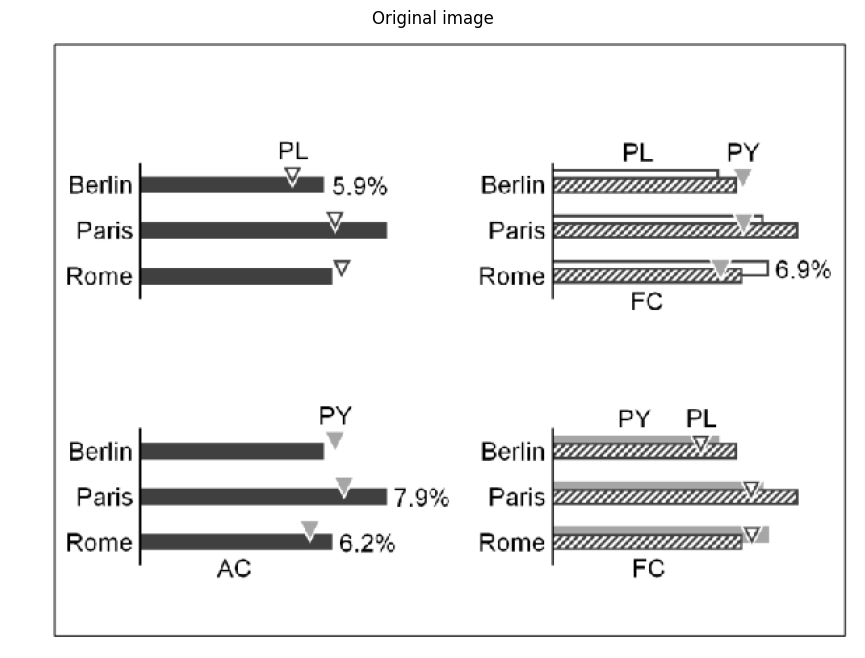

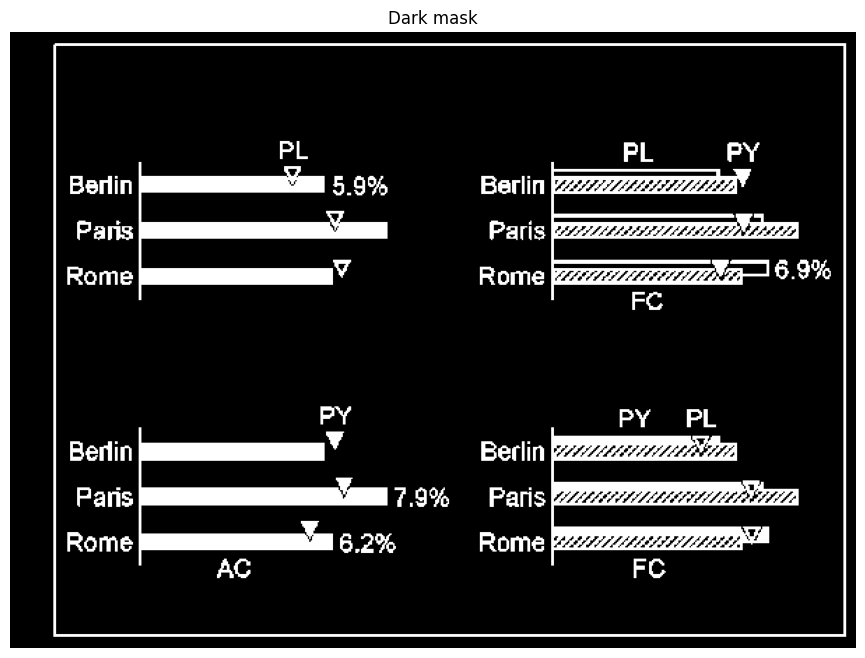

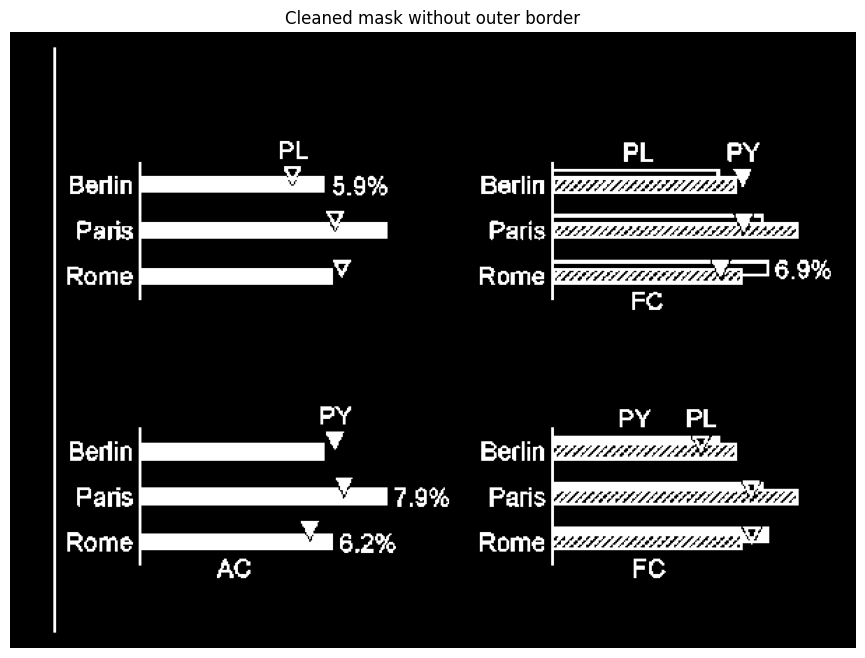

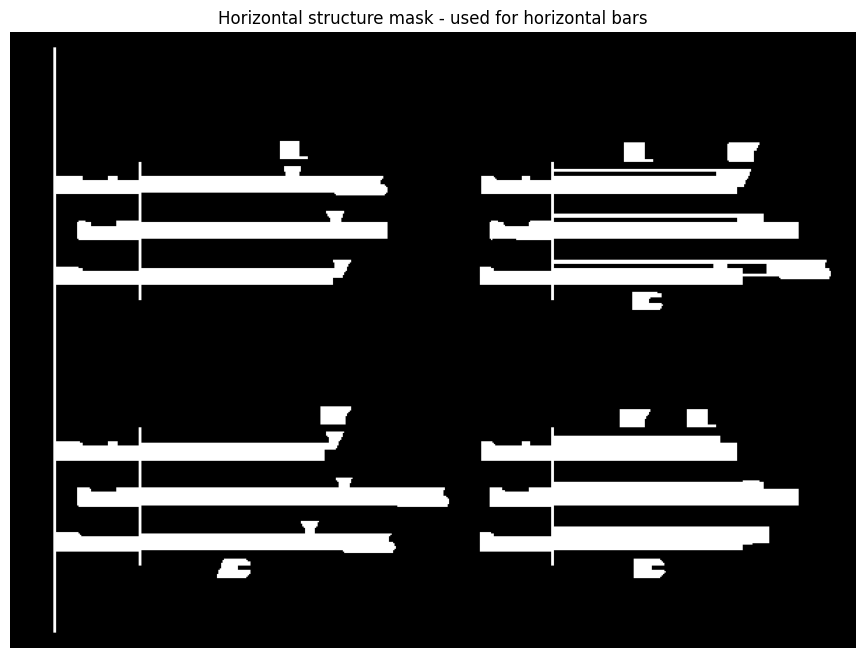

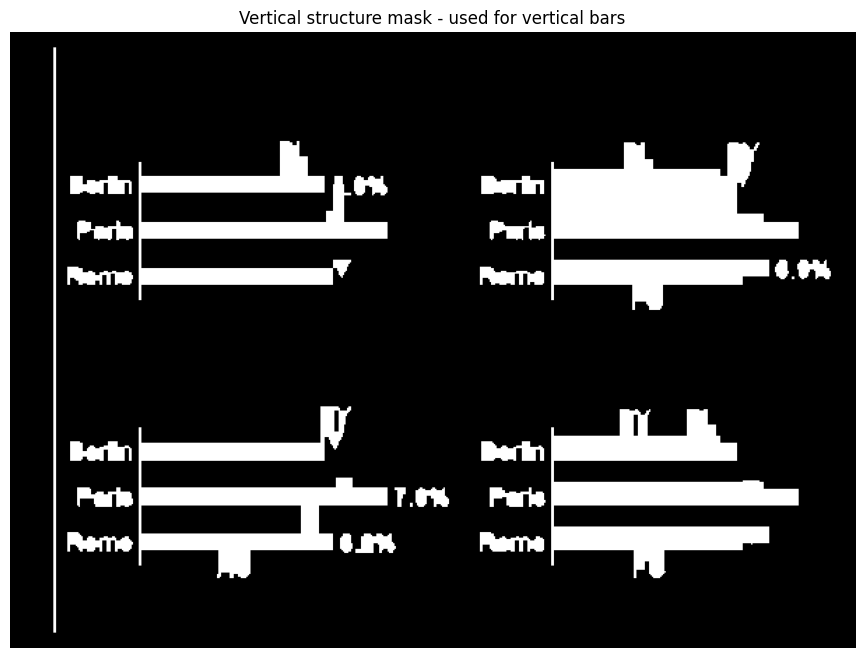

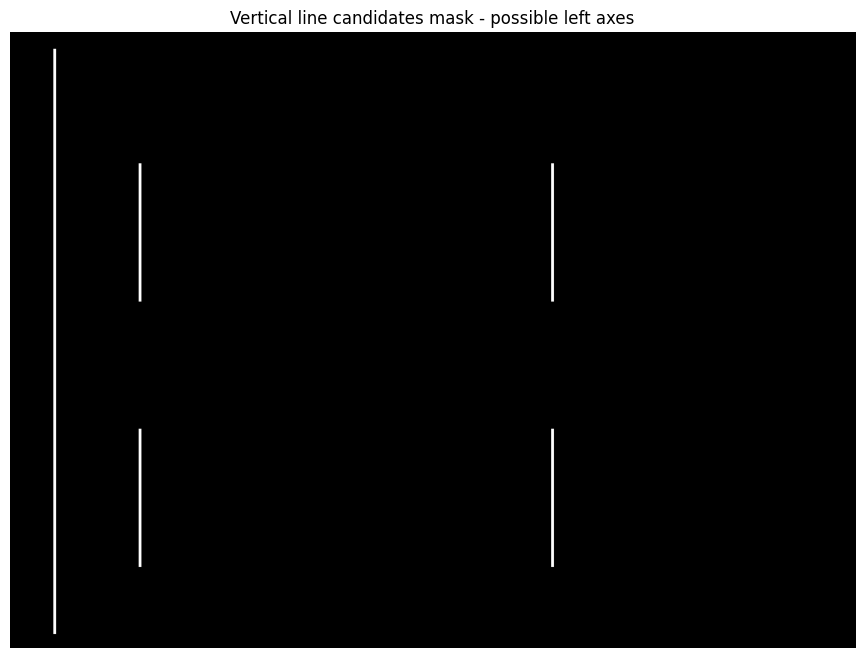

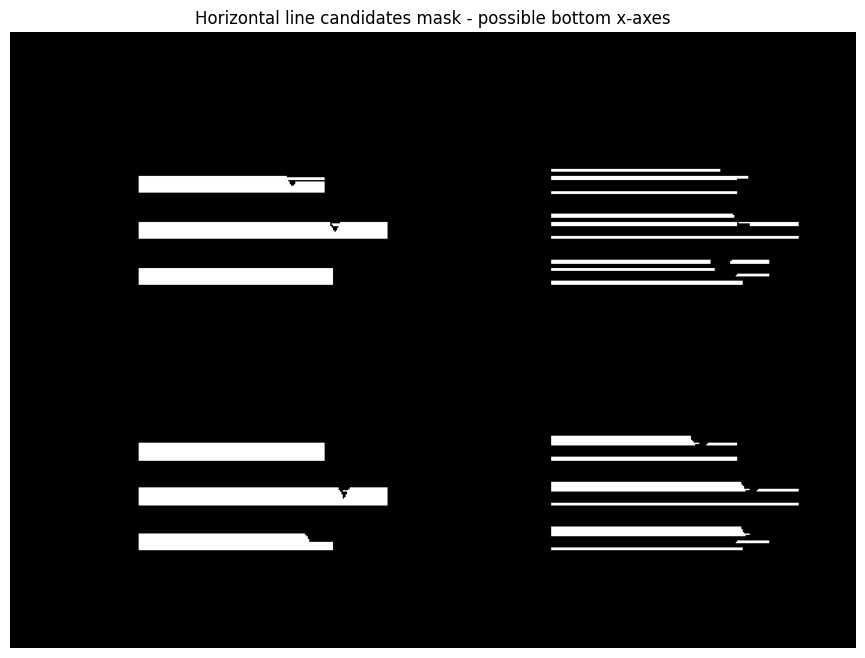

Horizontal bars found: 0
Vertical bars found: 0
Vertical line candidates: 4
Horizontal line candidates: 18
Left axes found: 0
Bottom x-axes found: 0
Fallback left axes: 0
Fallback bottom axes: 0
Total axes found: 0


In [4]:
image = load_image(IMAGE_PATH)
show_image("Original image", image)

result = run_best_axis_detection(image)

show_image("Dark mask", result["dark_mask"])
show_image("Cleaned mask without outer border", result["cleaned_mask"])

show_image("Horizontal structure mask - used for horizontal bars", result["horizontal_structure_mask"])
show_image("Vertical structure mask - used for vertical bars", result["vertical_structure_mask"])

show_image("Vertical line candidates mask - possible left axes", result["vertical_lines_mask"])
show_image("Horizontal line candidates mask - possible bottom x-axes", result["horizontal_lines_mask"])

print("Horizontal bars found:", len(result["horizontal_bars"]))
print("Vertical bars found:", len(result["vertical_bars"]))
print("Vertical line candidates:", len(result["vertical_lines"]))
print("Horizontal line candidates:", len(result["horizontal_lines"]))
print("Left axes found:", len(result["left_axes"]))
print("Bottom x-axes found:", len(result["bottom_axes"]))
print("Fallback left axes:", len(result["fallback_left_axes"]))
print("Fallback bottom axes:", len(result["fallback_bottom_axes"]))
print("Total axes found:", len(result["axes"]))

## 4. Final detection result

- Oranje boxes = horizontale bar-kandidaten
- Roze boxes = verticale bar-kandidaten
- Blauw = linker as voor horizontal bar chart
- Groen = onderste x-as voor vertical bar chart


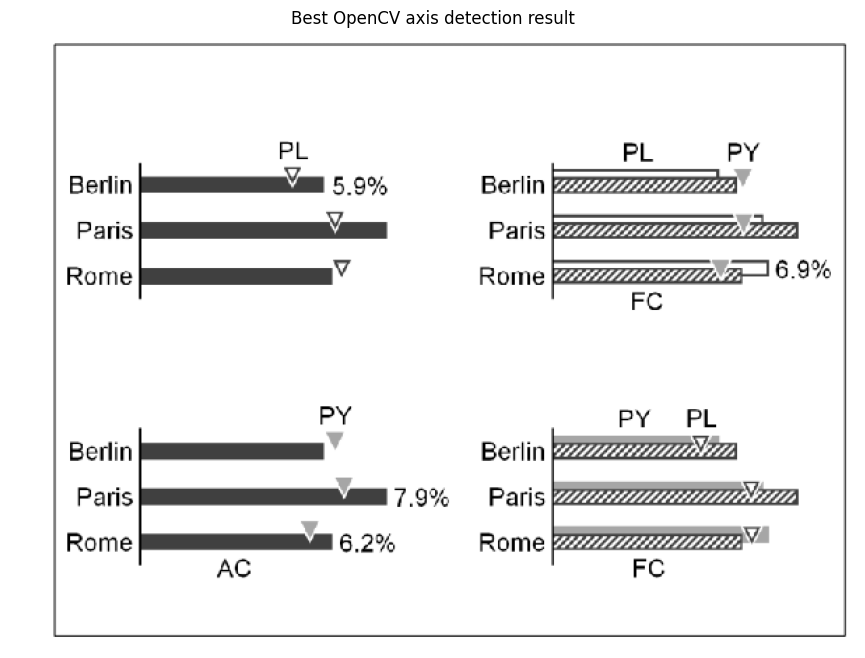

Saved result to: ..\output\7_best_axis_detection.png


In [5]:
output = draw_detection_result(image, result, max_axes=MAX_AXES_TO_DRAW)
show_image("Best OpenCV axis detection result", output)

output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_best_axis_detection.png"
cv2.imwrite(str(output_path), output)

print("Saved result to:", output_path)

## 5. Debug tables

Deze tabellen helpen om te controleren waarom iets wel of niet wordt gedetecteerd.


In [6]:
print("Horizontal bars:")
display(bars_to_dataframe(result["horizontal_bars"]).head(50))

print("Vertical bars:")
display(bars_to_dataframe(result["vertical_bars"]).head(50))

print("Vertical line candidates:")
display(lines_to_dataframe(result["vertical_lines"]).head(50))

print("Horizontal line candidates:")
display(lines_to_dataframe(result["horizontal_lines"]).head(50))

print("Detected axes:")
display(axes_to_dataframe(result["axes"]))

Horizontal bars:


""


Vertical bars:


""


Vertical line candidates:


,orientation,x1,y1,x2,y2,width,height
0,vertical_line,388,284,388,383,2,99
1,vertical_line,93,284,93,383,2,99
2,vertical_line,388,94,388,193,2,99
3,vertical_line,93,94,93,193,2,99


Horizontal line candidates:


,orientation,x1,y1,x2,y2,width,height
0,horizontal_line,387,370,524,370,137,2
1,horizontal_line,387,357,529,357,142,7
2,horizontal_line,387,338,564,338,177,2
3,horizontal_line,534,328,564,328,30,2
4,horizontal_line,387,325,529,325,142,7
5,horizontal_line,387,305,520,305,133,3
6,horizontal_line,387,292,493,292,106,7
7,horizontal_line,387,179,524,179,137,3
8,horizontal_line,387,170,504,170,117,2
9,horizontal_line,515,164,543,164,28,3


Detected axes:


""


## 6. Batch test on the whole dataset

Deze cel runt de detectie op alle afbeeldingen in:

```text
Dataset/Compliant
Dataset/Non-Compliant
```

De output wordt opgeslagen in:

```text
output/best_axis_detection_batch
```


In [7]:
DATASET_DIR = Path("../Dataset")
BATCH_OUTPUT_DIR = OUTPUT_DIR / "best_axis_detection_batch"
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_extensions = [".png", ".jpg", ".jpeg", ".webp"]
image_paths = []

for ext in image_extensions:
    image_paths.extend(DATASET_DIR.rglob(f"*{ext}"))

print("Found images:", len(image_paths))

summary_rows = []

for path in image_paths:
    try:
        img = load_image(path)
        res = run_best_axis_detection(img)
        out = draw_detection_result(img, res, max_axes=MAX_AXES_TO_DRAW)

        relative = path.relative_to(DATASET_DIR)
        save_path = BATCH_OUTPUT_DIR / relative
        save_path.parent.mkdir(parents=True, exist_ok=True)

        cv2.imwrite(str(save_path), out)

        summary_rows.append({
            "image": str(relative),
            "horizontal_bars": len(res["horizontal_bars"]),
            "vertical_bars": len(res["vertical_bars"]),
            "left_axes": len(res["left_axes"]),
            "bottom_axes": len(res["bottom_axes"]),
            "fallback_left_axes": len(res["fallback_left_axes"]),
            "fallback_bottom_axes": len(res["fallback_bottom_axes"]),
            "total_axes": len(res["axes"]),
            "output": str(save_path)
        })

        print("Saved:", save_path)

    except Exception as e:
        print("Error with", path, ":", e)

summary_df = pd.DataFrame(summary_rows)
summary_df

Found images: 360
Saved: ..\output\best_axis_detection_batch\Compliant\10.png
Saved: ..\output\best_axis_detection_batch\Compliant\100.png
Saved: ..\output\best_axis_detection_batch\Compliant\101.png
Saved: ..\output\best_axis_detection_batch\Compliant\102.png
Saved: ..\output\best_axis_detection_batch\Compliant\103.png
Saved: ..\output\best_axis_detection_batch\Compliant\104.png
Saved: ..\output\best_axis_detection_batch\Compliant\105.png
Saved: ..\output\best_axis_detection_batch\Compliant\106.png
Saved: ..\output\best_axis_detection_batch\Compliant\107.png
Saved: ..\output\best_axis_detection_batch\Compliant\108.png
Saved: ..\output\best_axis_detection_batch\Compliant\109.png
Saved: ..\output\best_axis_detection_batch\Compliant\11.png
Saved: ..\output\best_axis_detection_batch\Compliant\110.png
Saved: ..\output\best_axis_detection_batch\Compliant\111.png
Saved: ..\output\best_axis_detection_batch\Compliant\112.png
Saved: ..\output\best_axis_detection_batch\Compliant\12.png
Saved: ..

,image,horizontal_bars,vertical_bars,left_axes,bottom_axes,fallback_left_axes,fallback_bottom_axes,total_axes,output
0,Compliant\10.png,5,0,0,0,0,0,0,..\output\best_axis_detection_batch\Compliant\...
1,Compliant\100.png,20,2,0,0,9,0,9,..\output\best_axis_detection_batch\Compliant\...
2,Compliant\101.png,4,3,0,0,1,1,2,..\output\best_axis_detection_batch\Compliant\...
3,Compliant\102.png,15,0,0,0,6,0,6,..\output\best_axis_detection_batch\Compliant\...
4,Compliant\103.png,4,0,0,0,0,0,0,..\output\best_axis_detection_batch\Compliant\...
...,...,...,...,...,...,...,...,...,...
355,Compliant\47.webp,3,0,0,0,0,0,0,..\output\best_axis_detection_batch\Compliant\...
356,Compliant\71.webp,34,0,0,0,4,0,4,..\output\best_axis_detection_batch\Compliant\...
357,Compliant\73.webp,6,0,0,0,0,0,0,..\output\best_axis_detection_batch\Compliant\...
358,Not-Compliant\110.webp,26,5,0,0,6,0,6,..\output\best_axis_detection_batch\Not-Compli...


## 7. Explanation for report

You can use this explanation:

> This notebook uses a rule-based OpenCV approach to detect axes in bar chart images. The method uses two separate pipelines because one image can contain both horizontal and vertical bar charts. In the horizontal bar chart pipeline, the algorithm detects horizontal bars and then searches for vertical left-side axis lines. A vertical line is accepted as an axis only if multiple horizontal bars start near that line. In the vertical bar chart pipeline, the algorithm detects vertical bars and then searches for horizontal bottom x-axis lines. A horizontal line is accepted as an x-axis only if multiple vertical bars end near that line. If a visible axis line is missing, a fallback method uses shared bar start positions or shared bar bottom positions. This makes the detection more robust for images with multiple small charts, missing axis lines, borders and divider lines.

Limitation:

> This approach is not a trained AI model. It is a rule-based computer vision pipeline. It can still make mistakes when bars are very small, when text or symbols look like bars, or when chart elements are not clearly separated. Therefore, the output should be interpreted as axis candidates and visually checked.
